# 01 Data Exploration
Exploratory analysis of the NSW traffic/NO2/weather dataset — 11 stations at daily
resolution, 8 metro stations at hourly resolution.

**Structure:**
- **Part 1: Getting to know the data**: where the stations are, what the traffic and
  weather look like on their own terms, before looking at any relationship to NO2.
- **Part 2: The traffic-NO2 relationship**: correlations, the AQ-distance effect, the
  diurnal photochemical cycle, and deeper statistical checks (significance testing,
  outliers, multicollinearity).

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
from scipy import stats
import seaborn as sns

pd.set_option('display.width', 150)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

daily = pd.read_csv('../data/processed/preprocessed_daily.csv',
                     parse_dates=['date'], dtype={'station_id': str}, low_memory=False)
hourly = pd.read_csv('../data/processed/preprocessed_hourly.csv',
                      parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

def classify_road(name):
    n = name.lower()
    if 'highway' in n or 'motorway' in n or 'freeway' in n:
        return 'Highway'
    elif 'road' in n or 'way' in n or 'drive' in n or 'parade' in n:
        return 'Major Road'
    else:
        return 'Local Street'

daily['road_type'] = daily['station_name'].apply(classify_road)
daily['heavy_pct'] = daily['traffic_volume_heavy'] / daily['traffic_volume_total'] * 100
daily['dow'] = daily['date'].dt.dayofweek
daily['is_weekend'] = daily['dow'] >= 5

print("Daily:", daily.shape, "|", daily['station_id'].nunique(), "stations")
print("Hourly:", hourly.shape, "|", hourly['station_id'].nunique(), "stations")

Daily: (4872, 30) | 11 stations
Hourly: (66785, 24) | 8 stations


# Part 1 Getting to know the data
Before looking at any relationship between traffic and NO2, it's worth just *looking* at each piece of the data on its own terms.

## 1.1 What fields do we have?

In [16]:
summary = pd.DataFrame({
    'dtype': daily.dtypes.astype(str),
    'non_null_count': daily.notna().sum(),
    'missing_pct': (daily.isna().mean()*100).round(1),
    'example_value': daily.iloc[0],
})
summary

,dtype,non_null_count,missing_pct,example_value
date,datetime64[us],4872,0.0,2024-01-01 00:00:00
station_id,str,4872,0.0,MUB001
station_name,str,4872,0.0,MUB001 - Melbourne Street
station_lat,float64,4872,0.0,-36.003071
station_lon,float64,4872,0.0,146.003235
station_suburb,str,4872,0.0,Mulwala
station_lga,str,4872,0.0,Corowa
traffic_volume_total,float64,4872,0.0,11876.0
traffic_volume_light,float64,4872,0.0,11074.0
traffic_volume_heavy,float64,4872,0.0,802.0


Several fields in the dataset have a high proportion of missing values, for example, (`temp_max_c`/`temp_min_c` ~62%, `humidity_pct`/`wind_speed_ms`
~39%). This is likely due to the dataset being compiled from different data sources, which provide varying levels of coverage for these variables. Therefore, the appropriate data source needs to be identified and selected for the final dataset. 

## 1.2 Where are the stations, and what kind of road is each one?

In [3]:
places = daily.drop_duplicates('station_id')[
    ['station_id','station_name','station_suburb','station_lga','station_lat','station_lon','road_type']
].sort_values('road_type').reset_index(drop=True)
places[['station_id','station_name','station_suburb','station_lga','road_type']]

,station_id,station_name,station_suburb,station_lga,road_type
0,6135-PR,6135-PR - M31 Hume Highway,Bowning,Yass Valley,Highway
1,6119-PR,6119-PR - Pacific Highway,Nabiac,Greater Taree,Highway
2,6109,6109 - M23 Federal Highway,Yarra,Goulburn Mulwaree,Highway
3,MUB001,MUB001 - Melbourne Street,Mulwala,Corowa,Local Street
4,7212,7212 - Stewart Avenue,Newcastle West,Newcastle,Local Street
5,7211,7211 - Lily Lane,Adamstown,Newcastle,Local Street
6,7216,7216 - Gladstone Avenue,Wollongong,Wollongong,Local Street
7,100001,100001 - Cambridge Street,Canley Heights,Fairfield,Local Street
8,6124,6124 - Macleay Valley Way,South Kempsey,Kempsey,Major Road
9,10011,10011 - New South Head Road,Edgecliff,Woollahra,Major Road


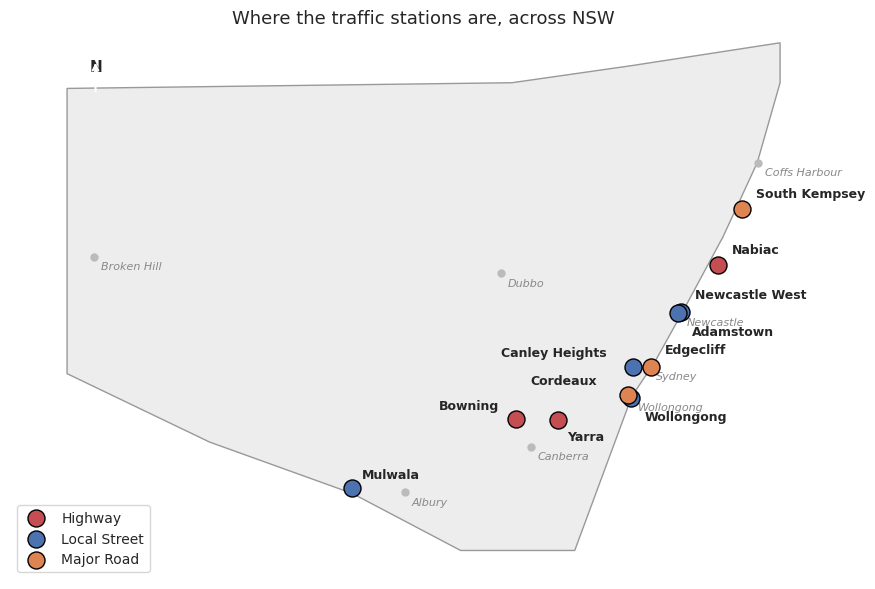

In [4]:
nsw_outline = [
    (141.0, -29.0), (141.0, -34.0), (143.5, -35.2), (146.0, -36.1),
    (147.9, -37.1), (149.9, -37.1), (150.9, -34.4), (151.3, -33.8),
    (151.8, -32.9), (152.5, -31.6), (153.1, -30.3), (153.5, -28.9),
    (153.5, -28.2), (150.9, -28.6), (148.8, -28.9), (141.0, -29.0),
]
reference_cities = {
    'Sydney': (151.21, -33.87), 'Newcastle': (151.75, -32.93), 'Wollongong': (150.89, -34.42),
    'Canberra': (149.13, -35.28), 'Dubbo': (148.61, -32.24), 'Albury': (146.92, -36.08),
    'Coffs Harbour': (153.11, -30.30), 'Broken Hill': (141.47, -31.95),
}
colors = {'Highway': '#C44E52', 'Major Road': '#DD8452', 'Local Street': '#4C72B0'}

fig, ax = plt.subplots(figsize=(9,9))
ax.add_patch(Polygon(nsw_outline, closed=True, facecolor='#EDEDED', edgecolor='#999999', zorder=1))
for city, (lon, lat) in reference_cities.items():
    ax.scatter(lon, lat, color='#BBBBBB', s=25, zorder=2)
    ax.annotate(city, (lon, lat), fontsize=8, color='#888888', xytext=(5,-9), textcoords='offset points',
                style='italic', zorder=2)
for road_type, group in places.groupby('road_type'):
    ax.scatter(group['station_lon'], group['station_lat'], label=road_type, color=colors[road_type],
               s=150, edgecolor='black', zorder=4)
label_offsets = {
    'Mulwala': (7,7), 'Bowning': (-55,7), 'Yarra': (7,-14), 'Newcastle West': (10,10),
    'Adamstown': (10,-16), 'Canley Heights': (-95,8), 'Edgecliff': (10,10),
    'Wollongong': (10,-16), 'Cordeaux': (-70,8), 'South Kempsey': (10,8), 'Nabiac': (10,8),
}
for _, row in places.iterrows():
    dx, dy = label_offsets.get(row['station_suburb'], (7,7))
    ax.annotate(row['station_suburb'], (row['station_lon'], row['station_lat']), fontsize=9,
                fontweight='bold', xytext=(dx,dy), textcoords='offset points', zorder=5)
ax.set_xlim(140, 154.5); ax.set_ylim(-37.6, -28)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_title('Where the traffic stations are, across NSW', fontsize=13)
ax.set_aspect('equal')
ax.annotate('N', xy=(141.5,-28.7), fontsize=11, fontweight='bold', ha='center')
ax.annotate('', xy=(141.5,-28.5), xytext=(141.5,-29.1), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.legend(loc='lower left', frameon=True)
plt.tight_layout(); plt.show()

Observation: Stations are concentrated in Sydney, Newcastle, and Wollongong, with a few remote regional stations. All three Highway stations are rural, while Local Street stations are mainly urban. This geographic pattern likely drives the AQ–distance effect observed in Part 2.

## 1.3 What does the traffic itself look like?

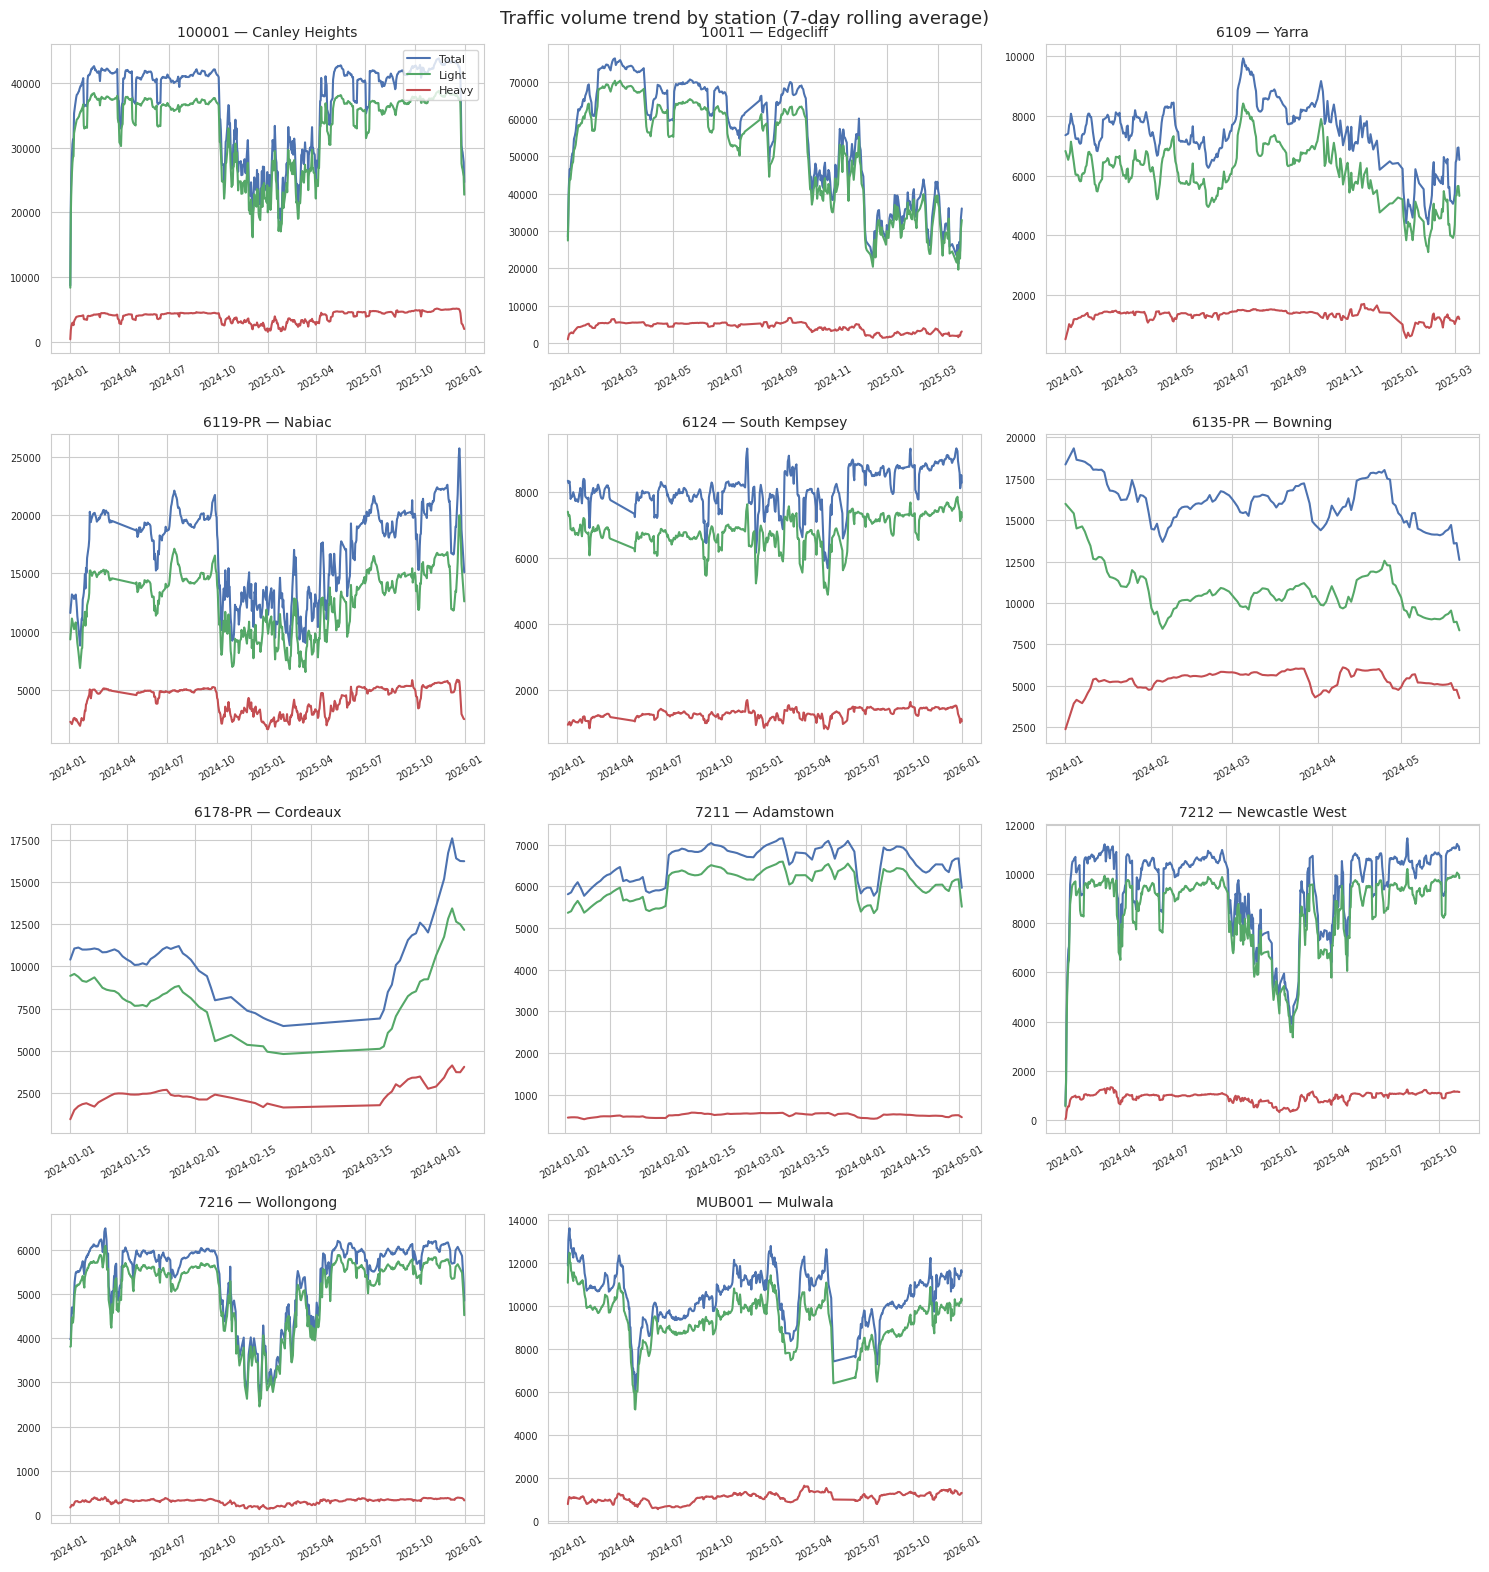

In [5]:
stations = sorted(daily['station_id'].unique())
n = len(stations); ncols = 3; nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()
for i, sid in enumerate(stations):
    ax = axes[i]
    g = daily[daily['station_id'] == sid].sort_values('date')
    ax.plot(g['date'], g['traffic_volume_total'].rolling(7, min_periods=1).mean(), label='Total', color='#4C72B0')
    ax.plot(g['date'], g['traffic_volume_light'].rolling(7, min_periods=1).mean(), label='Light', color='#55A868')
    ax.plot(g['date'], g['traffic_volume_heavy'].rolling(7, min_periods=1).mean(), label='Heavy', color='#C44E52')
    ax.set_title(f"{sid} — {g['station_suburb'].iloc[0]}", fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=7); ax.tick_params(axis='y', labelsize=7)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Traffic volume trend by station (7-day rolling average)', fontsize=13)
plt.tight_layout(); plt.show()

**Observation:** Several stations show sharp dips in data around Aug–Oct 2024 and Dec 2024–Jan 2025. The similar timing across stations suggests a shared data collection gap rather than a real traffic change. Stations 6135-PR, 6178-PR, and 7211 also have notably short data windows.

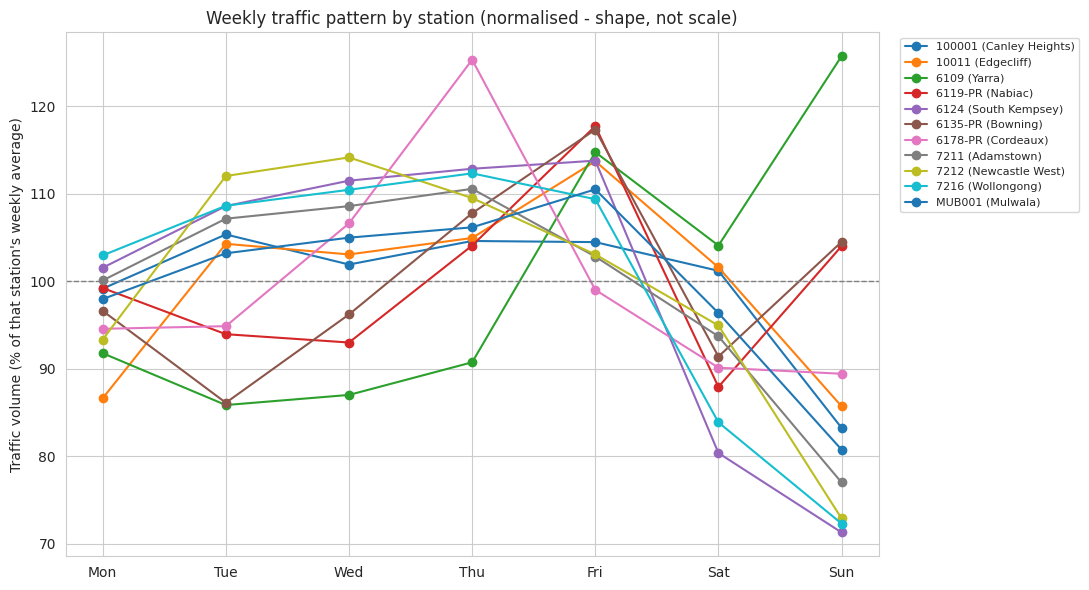

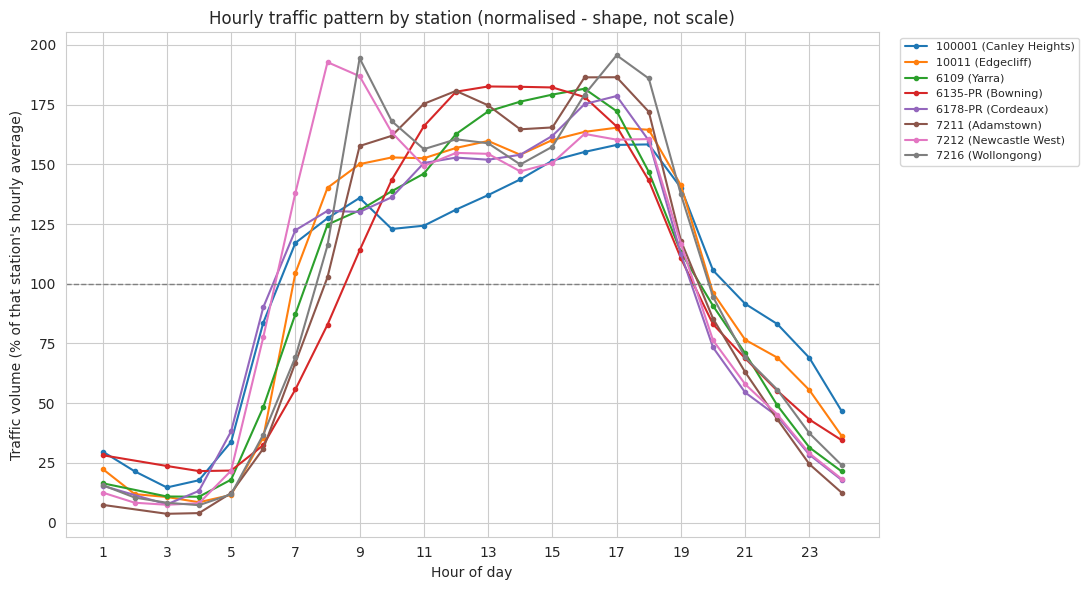

In [6]:
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig, ax = plt.subplots(figsize=(11,6))
for sid, g in daily.groupby('station_id'):
    weekly = g.groupby('dow')['traffic_volume_total'].mean()
    weekly_norm = weekly / weekly.mean() * 100
    suburb = g['station_suburb'].iloc[0]
    ax.plot(dow_labels, weekly_norm.values, marker='o', label=f"{sid} ({suburb})")
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel("Traffic volume (% of that station's weekly average)")
ax.set_title('Weekly traffic pattern by station (normalised - shape, not scale)')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11,6))
for sid, g in hourly.groupby('station_id'):
    hp = g.groupby('hour_ending')['traffic_volume_total'].mean()
    hp_norm = hp / hp.mean() * 100
    suburb = g['station_suburb'].iloc[0]
    ax.plot(hp.index, hp_norm.values, marker='o', markersize=3, label=f"{sid} ({suburb})")
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Hour of day'); ax.set_ylabel("Traffic volume (% of that station's hourly average)")
ax.set_title('Hourly traffic pattern by station (normalised - shape, not scale)')
ax.set_xticks(range(1,25,2))
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

**Finding:** Most stations show higher traffic volumes on weekdays and lower volumes on weekends, suggesting more regular commuter traffic during the week.**Yarra (6109)** is an exception, with higher Sunday activity, likely reflecting weekend intercity travel. **Bowning (6135-PR)** shows a milder version of this pattern. Hourly traffic patterns are more consistent across all eight stations, with no clear outliers.

## 1.4 What's the weather like across these places?

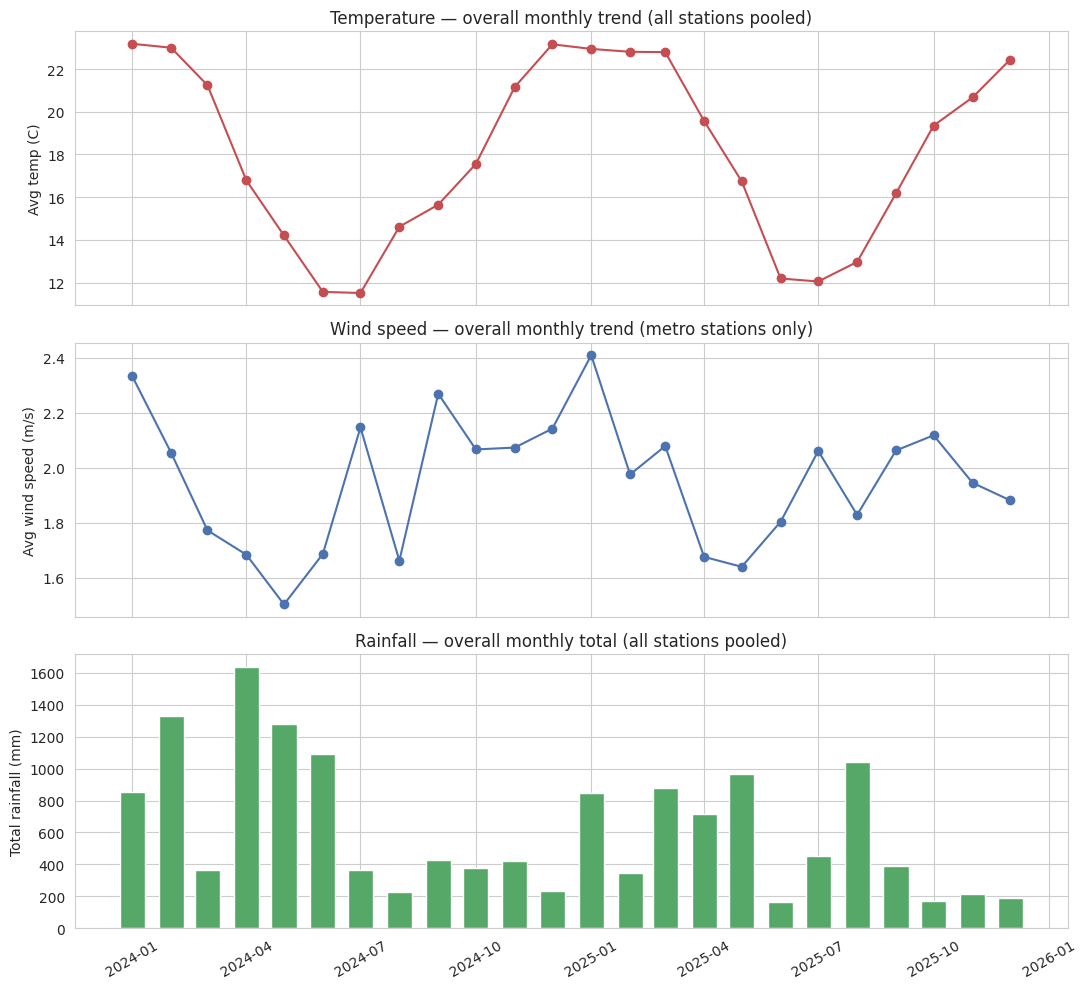

In [7]:
df_month = daily.copy()
df_month['month'] = df_month['date'].dt.to_period('M').dt.to_timestamp()
monthly = df_month.groupby('month').agg(
    avg_temp=('temp_c','mean'), avg_wind=('wind_speed_ms','mean'), total_rain=('rain_mm','sum')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(11,10), sharex=True)
axes[0].plot(monthly['month'], monthly['avg_temp'], marker='o', color='#C44E52')
axes[0].set_ylabel('Avg temp (C)'); axes[0].set_title('Temperature — overall monthly trend (all stations pooled)')
axes[1].plot(monthly['month'], monthly['avg_wind'], marker='o', color='#4C72B0')
axes[1].set_ylabel('Avg wind speed (m/s)'); axes[1].set_title('Wind speed — overall monthly trend (metro stations only)')
axes[2].bar(monthly['month'], monthly['total_rain'], width=20, color='#55A868')
axes[2].set_ylabel('Total rainfall (mm)'); axes[2].set_title('Rainfall — overall monthly total (all stations pooled)')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Observation:** Temperature shows a clear seasonal pattern, with higher temperatures in summer and lower temperatures in winter across both years. Wind and rainfall are more variable, with no clear seasonal pattern.

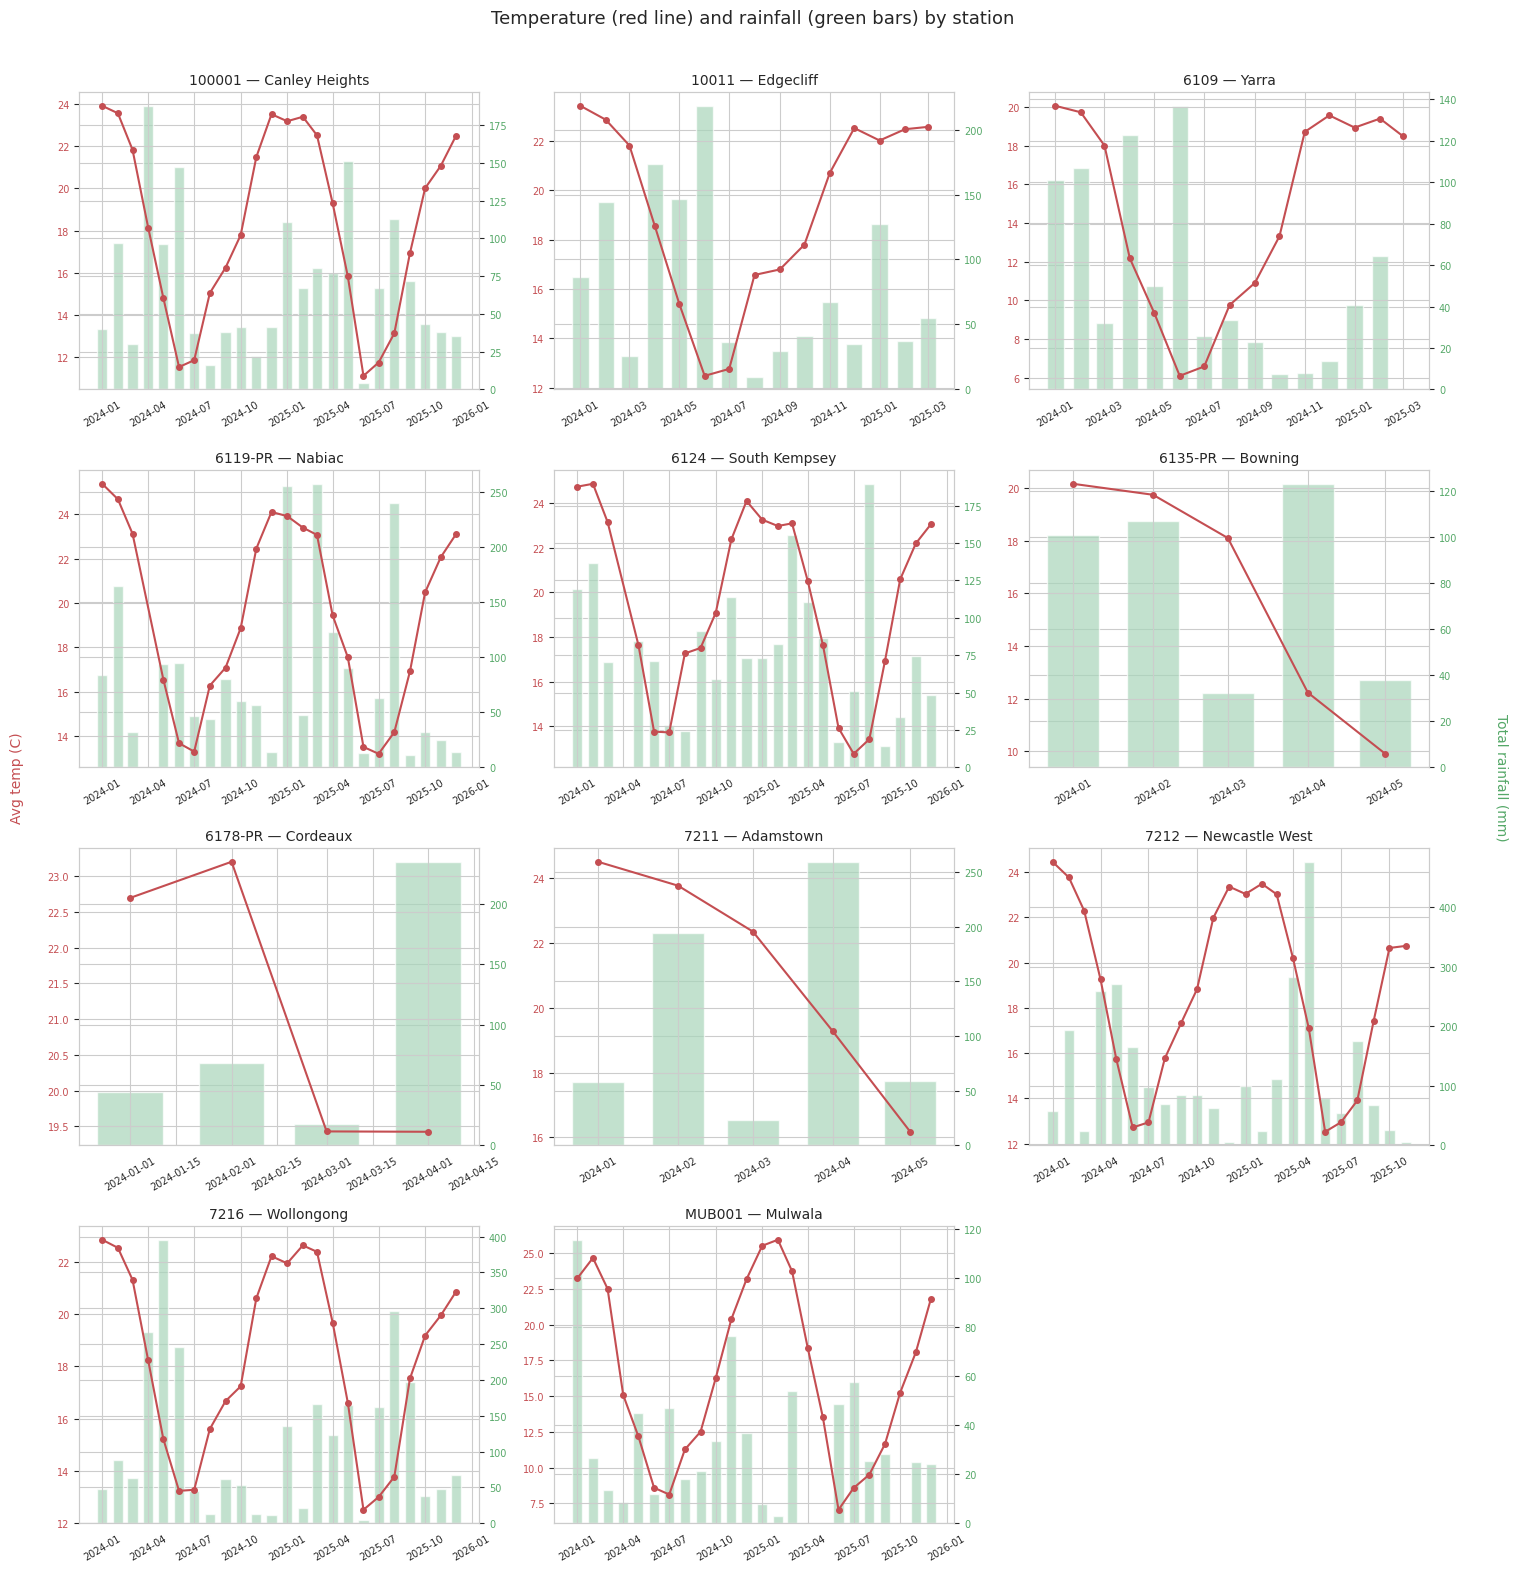

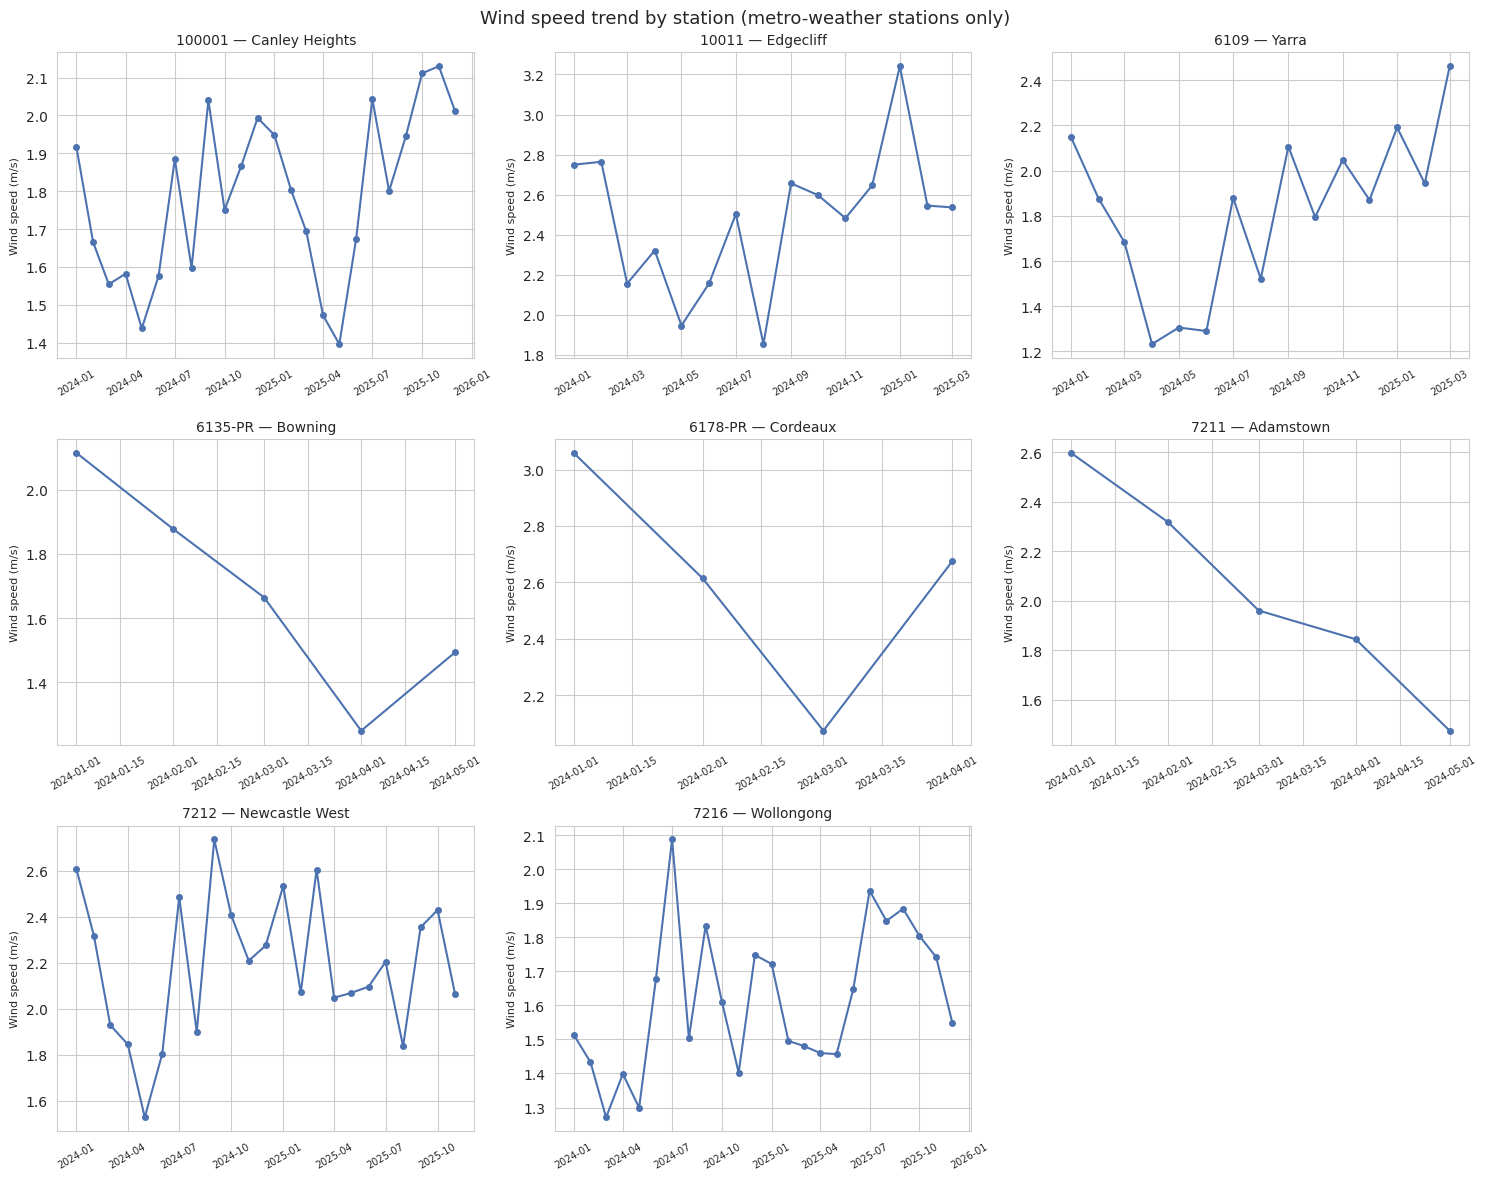

In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()
for i, sid in enumerate(stations):
    g = df_month[df_month['station_id'] == sid]
    m = g.groupby('month').agg(avg_temp=('temp_c','mean'), total_rain=('rain_mm','sum')).reset_index()
    suburb = g['station_suburb'].iloc[0]
    ax1 = axes[i]; ax2 = ax1.twinx()
    ax2.bar(m['month'], m['total_rain'], width=20, color='#A8D5BA', alpha=0.7, zorder=1)
    ax1.plot(m['month'], m['avg_temp'], marker='o', color='#C44E52', zorder=2, markersize=4)
    ax1.set_title(f"{sid} — {suburb}", fontsize=10)
    ax1.tick_params(axis='x', rotation=30, labelsize=7)
    ax1.tick_params(axis='y', labelsize=7, labelcolor='#C44E52')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='#55A868')
    ax1.set_zorder(2); ax1.patch.set_visible(False)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Temperature (red line) and rainfall (green bars) by station', fontsize=13)
fig.text(0.005, 0.5, 'Avg temp (C)', va='center', rotation='vertical', fontsize=10, color='#C44E52')
fig.text(0.995, 0.5, 'Total rainfall (mm)', va='center', rotation=-90, fontsize=10, color='#55A868')
plt.tight_layout(rect=[0.02,0,0.98,0.97]); plt.show()

wind_stations = sorted(daily.loc[daily['wind_speed_ms'].notna(), 'station_id'].unique())
nw = len(wind_stations); ncw = 3; nrw = -(-nw // ncw)
fig, axes = plt.subplots(nrw, ncw, figsize=(15, 4*nrw))
axes = axes.flatten()
for i, sid in enumerate(wind_stations):
    g = df_month[df_month['station_id'] == sid]
    m = g.groupby('month')['wind_speed_ms'].mean().reset_index()
    suburb = g['station_suburb'].iloc[0]
    axes[i].plot(m['month'], m['wind_speed_ms'], marker='o', color='#4C72B0', markersize=4)
    axes[i].set_title(f"{sid} — {suburb}", fontsize=10)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)
    axes[i].set_ylabel('Wind speed (m/s)', fontsize=8)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Wind speed trend by station (metro-weather stations only)', fontsize=13)
plt.tight_layout(); plt.show()

**Observation:** All stations show the same seasonal temperature pattern, with no clear outliers. The short-coverage stations (6135-PR, 6178-PR, 7211) have the same limited date range as the traffic data, suggesting a shared data availability limitation.

## 1.5 Weather deep-dive: does weather relate to NO2, to itself, and does rain change anything?
This section examines whether weather variables are related to NO₂, whether they are related to each other, and whether rainfall changes NO₂ or traffic behaviour.

### Weather vs NO2, with significance testing
Correlation shows the strength and direction of a relationship, but significance testing helps determine whether the observed relationship is likely to be meaningful rather than due to random variation.

In [9]:
from scipy import stats

weather_vars = ['temp_c', 'humidity_pct', 'wind_speed_ms', 'rain_mm']
results = []
for var in weather_vars:
    paired = daily[[var, 'no2_pphm']].dropna()
    r, p = stats.pearsonr(paired[var], paired['no2_pphm'])
    results.append({
        'weather_variable': var, 'n_pairs': len(paired),
        'pearson_r': round(r, 3), 'p_value': p, 'significant (p<0.05)': p < 0.05,
    })
pd.DataFrame(results)

,weather_variable,n_pairs,pearson_r,p_value,significant (p<0.05)
0,temp_c,4857,-0.261,1.360612e-76,True
1,humidity_pct,2978,0.017,3.413022e-01,False
2,wind_speed_ms,2959,-0.375,1.427133e-99,True
3,rain_mm,4855,-0.061,2.054347e-05,True


**Finding:** Wind speed and temperature show meaningful negative relationships with NO₂ (r = −0.375 and −0.261, respectively), both highly significant (p < 0.001). Rainfall is statistically significant but has only a very weak relationship (r = −0.061), so the effect size is more important than the p-value. **Humidity shows no significant relationship with NO₂** (p = 0.34, r ≈ 0.02) and could be excluded as a feature.


### Does rain actually change NO2, and does it change traffic?
This section looks at whether rainfall affects NO₂ directly by reducing pollutants in the air, or indirectly by changing traffic behaviour. Comparing rainy and non-rainy days can help distinguish between these effects.

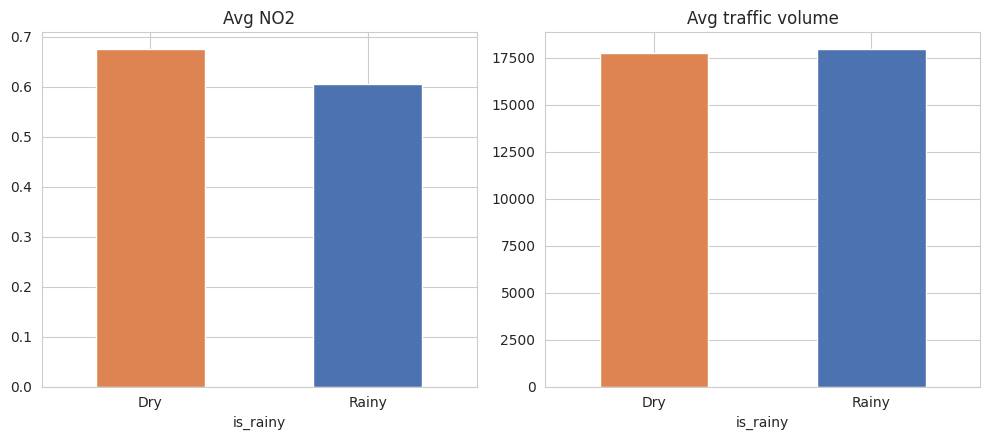

Rainy days: n=1185, dry days: n=3687

NO2 -- rainy mean: 0.606, dry mean: 0.675
  t=-4.34, p=1.49e-05, significant=True

Traffic -- rainy mean: 17947, dry mean: 17748
  t=0.34, p=7.31e-01, significant=False


In [10]:
daily['is_rainy'] = daily['rain_mm'] > 1.0  # >1mm = a "rainy day"

rainy_no2 = daily.loc[daily['is_rainy'], 'no2_pphm'].dropna()
dry_no2 = daily.loc[~daily['is_rainy'], 'no2_pphm'].dropna()
t1, p1 = stats.ttest_ind(rainy_no2, dry_no2, equal_var=False)

rainy_traffic = daily.loc[daily['is_rainy'], 'traffic_volume_total'].dropna()
dry_traffic = daily.loc[~daily['is_rainy'], 'traffic_volume_total'].dropna()
t2, p2 = stats.ttest_ind(rainy_traffic, dry_traffic, equal_var=False)

fig, axes = plt.subplots(1,2, figsize=(10,4.5))
daily.groupby('is_rainy')['no2_pphm'].mean().rename({False:'Dry',True:'Rainy'}).plot.bar(ax=axes[0], color=['#DD8452','#4C72B0'])
axes[0].set_title('Avg NO2'); axes[0].tick_params(axis='x', rotation=0)
daily.groupby('is_rainy')['traffic_volume_total'].mean().rename({False:'Dry',True:'Rainy'}).plot.bar(ax=axes[1], color=['#DD8452','#4C72B0'])
axes[1].set_title('Avg traffic volume'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print(f"Rainy days: n={len(rainy_no2)}, dry days: n={len(dry_no2)}")
print(f"\nNO2 -- rainy mean: {rainy_no2.mean():.3f}, dry mean: {dry_no2.mean():.3f}")
print(f"  t={t1:.2f}, p={p1:.2e}, significant={p1<0.05}")
print(f"\nTraffic -- rainy mean: {rainy_traffic.mean():.0f}, dry mean: {dry_traffic.mean():.0f}")
print(f"  t={t2:.2f}, p={p2:.2e}, significant={p2<0.05}")

**Finding:** NO₂ is significantly lower on rainy days (p ≈ 1.5e-05), while **traffic volume does not significantly differ** between rainy and dry days (p = 0.73). This suggests that the reduction in NO₂ is more likely due to a direct atmospheric effect of rainfall, such as wet deposition, rather than reduced traffic.

### Do the weather variables relate to each other?
This checks for relationships between weather variables to identify potential multicollinearity before feature engineering. Highly correlated variables may provide redundant information when included in the model.

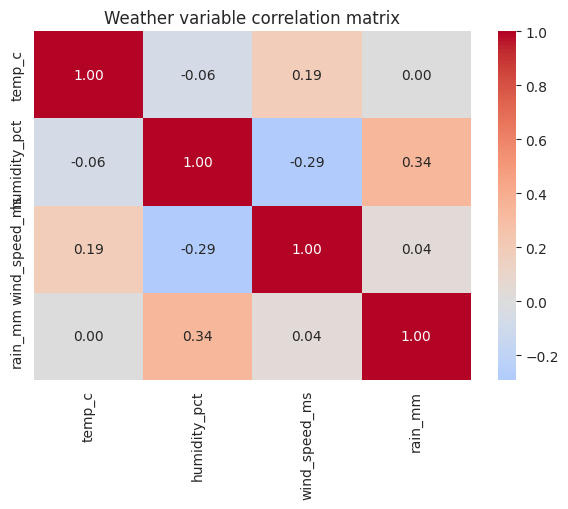

In [11]:
fig, ax = plt.subplots(figsize=(6,5.2))
sns.heatmap(daily[weather_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Weather variable correlation matrix')
plt.tight_layout(); plt.show()

**Finding:** Weather variables are only weakly correlated with each other, with the strongest relationship between humidity and rainfall (r = 0.34). There is no serious multicollinearity concern, so temperature, humidity, wind speed, and rainfall can be included as separate features.

# Part 2 — The traffic-NO2 relationship

## 2.1 NO2 distribution

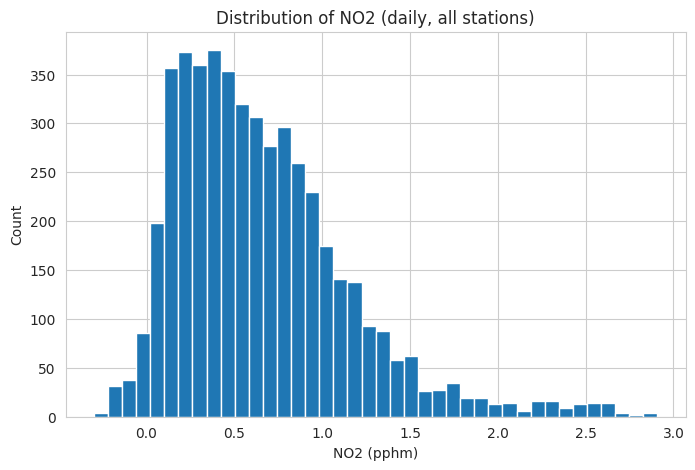

Skewness: 1.26  (0 = symmetric; >0 = right-skewed, long tail toward high values)
Kurtosis: 2.25  (0 = normal-like tails; >0 = heavier tails / more extreme values than normal)


count    4872.000000
mean        0.658248
std         0.497709
min        -0.300000
25%         0.290801
50%         0.566667
75%         0.908333
max         2.909091
Name: no2_pphm, dtype: float64

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
daily['no2_pphm'].hist(bins=40, ax=ax, edgecolor='white')
ax.set_xlabel('NO2 (pphm)'); ax.set_ylabel('Count'); ax.set_title('Distribution of NO2 (daily, all stations)')
plt.show()

skew = stats.skew(daily['no2_pphm'].dropna())
kurt = stats.kurtosis(daily['no2_pphm'].dropna())
print(f"Skewness: {skew:.2f}  (0 = symmetric; >0 = right-skewed, long tail toward high values)")
print(f"Kurtosis: {kurt:.2f}  (0 = normal-like tails; >0 = heavier tails / more extreme values than normal)")
daily['no2_pphm'].describe()

**Finding:** NO₂ is right-skewed (skewness ≈ 1.26) with heavier tails than a normal distribution (kurtosis ≈ 2.25). A small number of slightly negative readings are likely sensor noise near the detection limit.

**Modeling implication:** A log transformation or a model that does not assume normally distributed errors may be more appropriate than a standard linear model using raw NO₂.

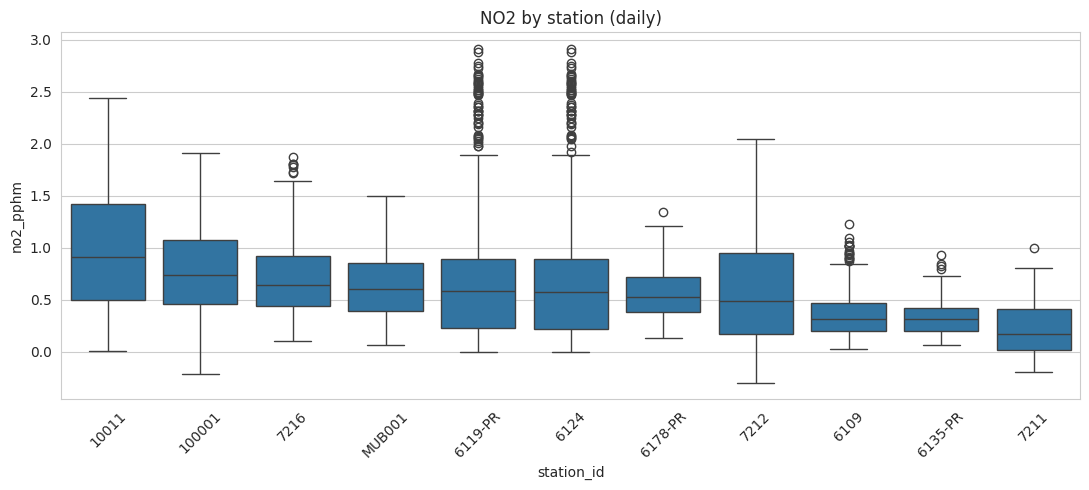

In [13]:
fig, ax = plt.subplots(figsize=(11,5))
no2_order = daily.groupby('station_id')['no2_pphm'].median().sort_values(ascending=False).index
sns.boxplot(data=daily, x='station_id', y='no2_pphm', order=no2_order, ax=ax)
ax.set_title('NO2 by station (daily)'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 1.2 Traffic vs NO2 — the core relationship

Overall daily Pearson r: 0.285


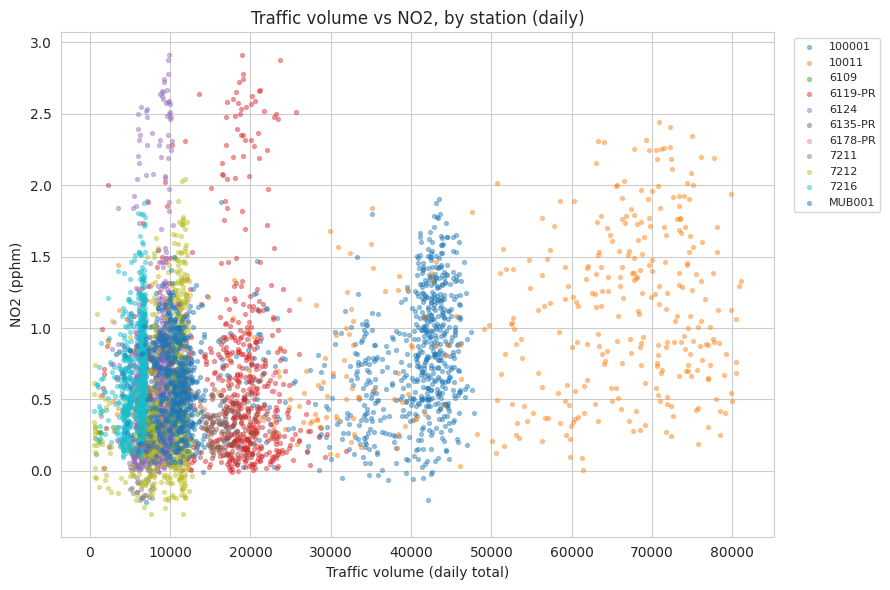

station_id
10011      0.399758
100001     0.338760
7216       0.322570
7212       0.267276
6124       0.099573
7211       0.042720
6178-PR    0.009885
6109      -0.044493
6119-PR   -0.104009
MUB001    -0.108295
6135-PR   -0.161281
Name: corr, dtype: float64

In [14]:
overall_pearson = daily['traffic_volume_total'].corr(daily['no2_pphm'])
print(f"Overall daily Pearson r: {overall_pearson:.3f}")

fig, ax = plt.subplots(figsize=(9,6))
for sid, g in daily.groupby('station_id'):
    ax.scatter(g['traffic_volume_total'], g['no2_pphm'], s=8, alpha=0.4, label=sid)
ax.set_xlabel('Traffic volume (daily total)'); ax.set_ylabel('NO2 (pphm)')
ax.set_title('Traffic volume vs NO2, by station (daily)')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

daily_corrs = daily.groupby('station_id').apply(lambda g: g['traffic_volume_total'].corr(g['no2_pphm'])).rename('corr')
daily_corrs.sort_values(ascending=False)

## 2.3 Key finding: AQ match distance drives relationship strength
Traffic has a much stronger relationship with NO₂ when the traffic station is close to its matched AQ site. This relationship weakens as the distance between the two sites increases, highlighting the importance of geographic proximity.

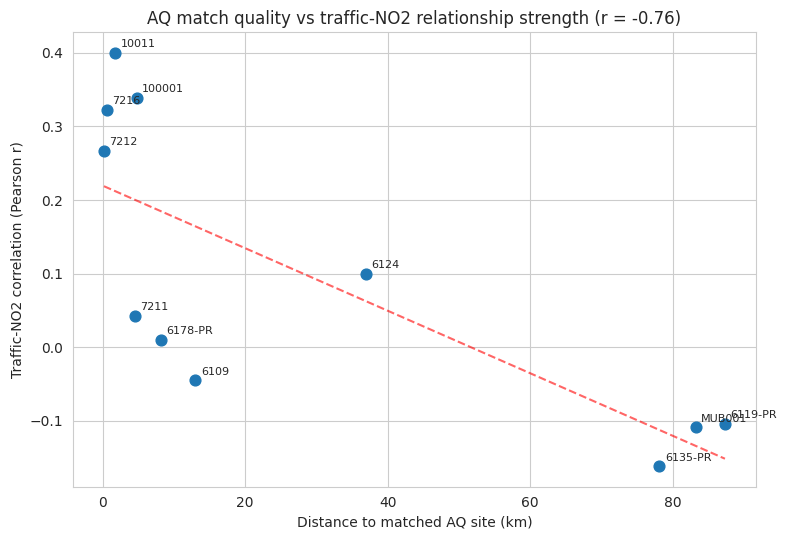

Correlation between (per-station traffic-NO2 correlation) and (AQ distance): -0.759


In [15]:
dist = daily.groupby('station_id')['aq_distance_km'].first().rename('distance_km')
combo = pd.concat([daily_corrs, dist], axis=1).sort_values('distance_km').reset_index()

fig, ax = plt.subplots(figsize=(8,5.5))
ax.scatter(combo['distance_km'], combo['corr'], s=60)
for _, row in combo.iterrows():
    ax.annotate(row['station_id'], (row['distance_km'], row['corr']), fontsize=8, xytext=(4,4), textcoords='offset points')
z = np.polyfit(combo['distance_km'], combo['corr'], 1)
xs = np.linspace(combo['distance_km'].min(), combo['distance_km'].max(), 50)
ax.plot(xs, np.polyval(z, xs), '--', color='red', alpha=0.6)
r = combo['corr'].corr(combo['distance_km'])
ax.set_xlabel('Distance to matched AQ site (km)'); ax.set_ylabel('Traffic-NO2 correlation (Pearson r)')
ax.set_title(f'AQ match quality vs traffic-NO2 relationship strength (r = {r:.2f})')
plt.tight_layout(); plt.show()
print(f"Correlation between (per-station traffic-NO2 correlation) and (AQ distance): {r:.3f}")

**Implication for modeling:**:`aq_distance_km` should be considered when selecting or weighting stations, or included as a model feature. Stations more than ~15–20 km apart show a weak or negative traffic–NO₂ relationship, suggesting their NO₂ measurements may be too geographically disconnected from the traffic data to model reliably.

## 2.4 Where do we expect more traffic — and more emissions?

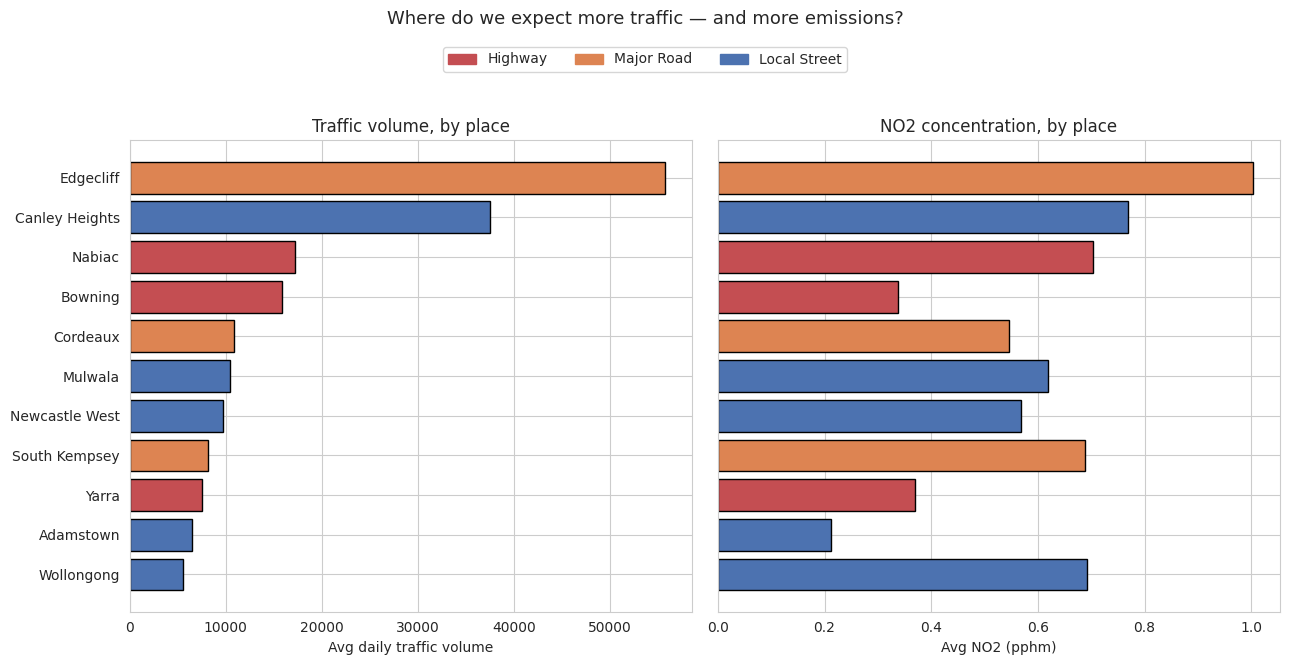

In [16]:
summary_place = daily.groupby(['station_id','station_suburb','road_type']).agg(
    avg_traffic=('traffic_volume_total','mean'), avg_no2=('no2_pphm','mean'),
).reset_index().sort_values('avg_traffic', ascending=True)
bar_colors = summary_place['road_type'].map(colors)

fig, axes = plt.subplots(1, 2, figsize=(13,6), sharey=True)
axes[0].barh(summary_place['station_suburb'], summary_place['avg_traffic'], color=bar_colors, edgecolor='black')
axes[0].set_xlabel('Avg daily traffic volume'); axes[0].set_title('Traffic volume, by place')
axes[1].barh(summary_place['station_suburb'], summary_place['avg_no2'], color=bar_colors, edgecolor='black')
axes[1].set_xlabel('Avg NO2 (pphm)'); axes[1].set_title('NO2 concentration, by place')
handles = [Patch(color=c, label=t) for t, c in colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Where do we expect more traffic — and more emissions?', y=1.1, fontsize=13)
plt.tight_layout(); plt.show()

**Finding:** Edgecliff and Canley Heights rank highly in both traffic volume and NO₂, matching expectations. **Bowning** is an exception, with high traffic but low NO₂, likely due to the poor geographic match with its rural AQ site. **Wollongong** shows the opposite pattern, with the lowest traffic volume but relatively high NO₂, suggesting that the nearby AQ site may be capturing other local emission sources in addition to traffic from the monitored street.

## 1.5 Weekday vs weekend — with a significance test

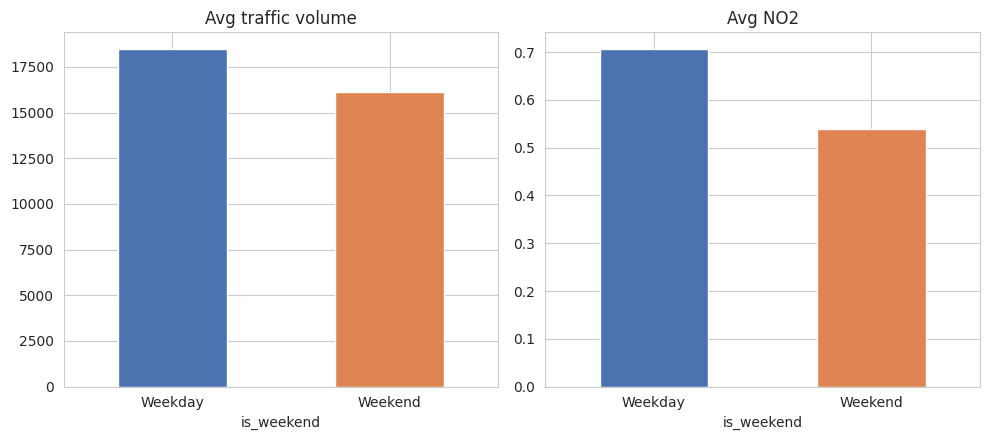

Weekday NO2 mean: 0.706  |  Weekend NO2 mean: 0.539
Welch's t-test: t = 11.07, p = 6.91e-28
-> statistically significant


In [17]:
wd = daily.loc[~daily['is_weekend'], 'no2_pphm'].dropna()
we = daily.loc[daily['is_weekend'], 'no2_pphm'].dropna()
t_stat, p_value = stats.ttest_ind(wd, we, equal_var=False)

fig, axes = plt.subplots(1,2, figsize=(10,4.5))
daily.groupby('is_weekend')['traffic_volume_total'].mean().rename({False:'Weekday',True:'Weekend'}).plot.bar(ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title('Avg traffic volume'); axes[0].tick_params(axis='x', rotation=0)
daily.groupby('is_weekend')['no2_pphm'].mean().rename({False:'Weekday',True:'Weekend'}).plot.bar(ax=axes[1], color=['#4C72B0','#DD8452'])
axes[1].set_title('Avg NO2'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print(f"Weekday NO2 mean: {wd.mean():.3f}  |  Weekend NO2 mean: {we.mean():.3f}")
print(f"Welch's t-test: t = {t_stat:.2f}, p = {p_value:.2e}")
print("-> statistically significant" if p_value < 0.05 else "-> not statistically significant")

**Finding:** The weekday/weekend difference in NO₂ is statistically significant (p < 0.001), confirming that the observed pattern is unlikely to be due to random variation. This supports including  `is_weekend`or`day_of_week` as a feature rather than treating the pattern as only a visual observation.

## 2.6 Heavy Vehicle Share and NO₂ by Road Type
Earlier (Part 1.3), we found that heavy-vehicle share varies substantially by road type. This section examines whether its relationship with NO₂ also differs by road type, rather than assuming the same relationship across all roads.

In [18]:
print("Pooled (all road types together):", daily['heavy_pct'].corr(daily['no2_pphm']).round(3))
print("\nBy road type:")
for rt, g in daily.groupby('road_type'):
    print(f"  {rt}: r = {g['heavy_pct'].corr(g['no2_pphm']):.3f}  (n={len(g)})")

Pooled (all road types together): -0.019

By road type:
  Highway: r = 0.121  (n=1116)
  Local Street: r = 0.183  (n=2666)
  Major Road: r = -0.098  (n=1090)


**Finding:** This confirms the pattern observed in Part 1.3. The pooled correlation (r ≈ −0.02) suggests almost no relationship, but analysing road types separately reveals positive relationships for Highway (r = 0.12) and Local Street (r = 0.18), and a negative relationship for Major Road (r = −0.10). Pooling the road types therefore hides differences between groups and loses useful information

**Modeling implication:** `road_type` (or an interaction between `road_type` and
`heavy_pct`) is likely to help, not just `heavy_pct` alone.

## 2.7 Multicollinearity check — full correlation matrix
Before feature engineering, it's worth seeing how the candidate predictors relate to
*each other*, not just to NO2. Two features that are highly correlated with each other
can cause problems for both model stability and explainability (SHAP/feature importance
gets harder to interpret when features overlap).

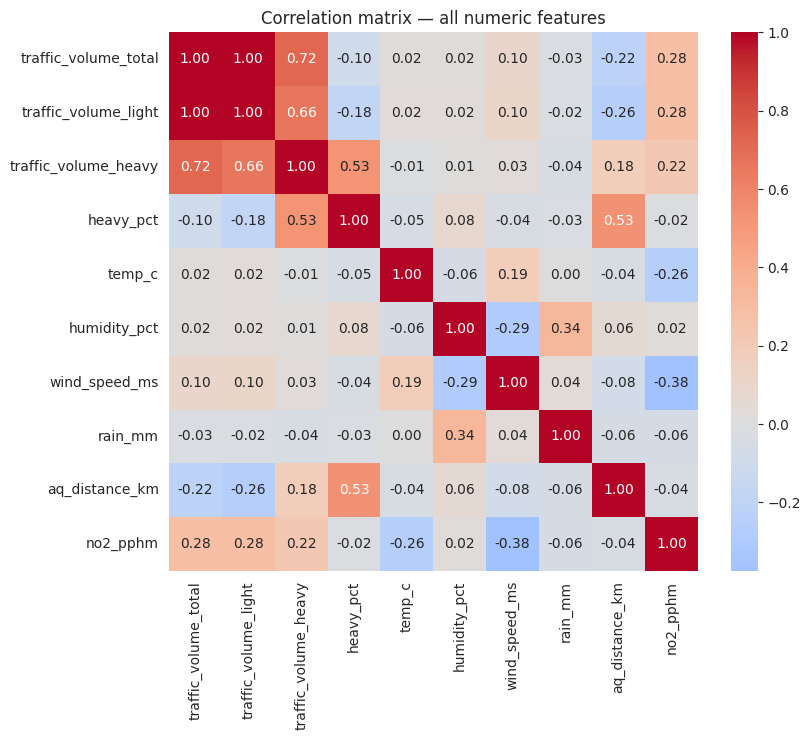

In [19]:
numeric_cols = ['traffic_volume_total','traffic_volume_light','traffic_volume_heavy','heavy_pct',
                'temp_c','humidity_pct','wind_speed_ms','rain_mm','aq_distance_km','no2_pphm']
fig, ax = plt.subplots(figsize=(8.5,7.5))
sns.heatmap(daily[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix — all numeric features')
plt.tight_layout(); plt.show()

**Finding:** `traffic_volume_total` and `traffic_volume_light` are very highly
correlated (as expected — light vehicles dominate total volume), which means including
both as separate features would be largely redundant. `temp_c` and `wind_speed_ms` are
only weakly correlated with each other, so both can safely be included without
redundancy concerns. **Modeling implication:** prefer `traffic_volume_total` +
`heavy_pct` over including `traffic_volume_light` and `traffic_volume_heavy` as three
separate near-duplicate columns.

## 2.8 Outlier check (IQR method)
A quick, standard check for extreme values per station, before deciding whether any need
special handling in feature engineering.

In [20]:
def count_outliers(g, col):
    q1, q3 = g[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((g[col] < lower) | (g[col] > upper)).sum()

outlier_summary = daily.groupby('station_id').apply(lambda g: pd.Series({
    'n_rows': len(g),
    'no2_outliers': count_outliers(g, 'no2_pphm'),
    'traffic_outliers': count_outliers(g, 'traffic_volume_total'),
}))
outlier_summary['no2_outlier_pct'] = (outlier_summary['no2_outliers'] / outlier_summary['n_rows'] * 100).round(1)
outlier_summary

,n_rows,no2_outliers,traffic_outliers,no2_outlier_pct
station_id,,,,
100001,704,0,69,0.0
10011,402,0,0,0.0
6109,358,18,16,5.0
6119-PR,621,49,15,7.9
6124,628,47,3,7.5
6135-PR,137,4,11,2.9
6178-PR,60,1,9,1.7
7211,116,1,4,0.9
7212,594,0,35,0.0


**Finding:** **6119-PR** (8% NO₂ outliers) and **6124** (7.5%) stand out. Both are matched to Port Macquarie, with traffic–AQ distances of 87 km and 37 km, respectively. This provides additional evidence that poorly matched stations may produce noisier NO₂ measurements, consistent with the correlation-by-distance analysis and traffic/NO₂ comparisons.

## 2.9 Hourly Traffic and NO₂ Patterns
The daily analysis averages across each day and can therefore hide patterns that occur within a day. Examining the data at hourly resolution allows us to investigate how the traffic–NO₂ relationship changes throughout the day.

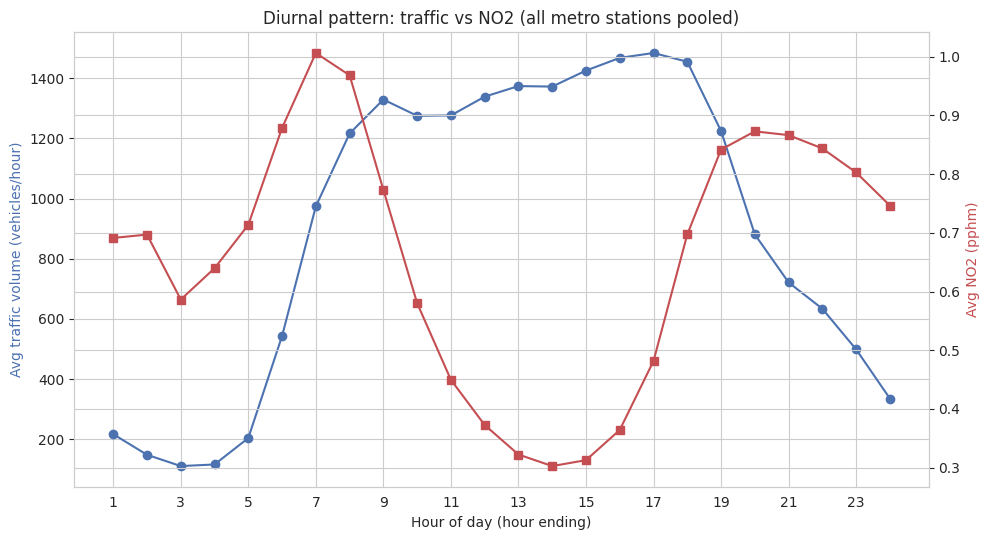

Hourly pooled Pearson r: 0.184  (vs daily pooled r: 0.285)


In [21]:
profile = hourly.groupby('hour_ending')[['traffic_volume_total','no2_pphm']].mean()
fig, ax1 = plt.subplots(figsize=(10,5.5))
ax2 = ax1.twinx()
ax1.plot(profile.index, profile['traffic_volume_total'], color='#4C72B0', marker='o', label='Traffic volume')
ax2.plot(profile.index, profile['no2_pphm'], color='#C44E52', marker='s', label='NO2')
ax1.set_xlabel('Hour of day (hour ending)')
ax1.set_ylabel('Avg traffic volume (vehicles/hour)', color='#4C72B0')
ax2.set_ylabel('Avg NO2 (pphm)', color='#C44E52')
ax1.set_title('Diurnal pattern: traffic vs NO2 (all metro stations pooled)')
ax1.set_xticks(range(1,25,2))
plt.tight_layout(); plt.show()

hourly_pearson = hourly['traffic_volume_total'].corr(hourly['no2_pphm'])
print(f"Hourly pooled Pearson r: {hourly_pearson:.3f}  (vs daily pooled r: {overall_pearson:.3f})")

**Finding:** Traffic increases from around 6am and remains high through the middle of the day. NO₂ shows a different pattern, peaking during the morning rush (~7–8am) before falling to its lowest levels around midday, when traffic is highest. This pattern is consistent with the daily NOₓ photochemical cycle, where sunlight contributes to the conversion of NO₂ into other pollutants. The hourly traffic–NO₂ correlation (r ≈ 0.18) is weaker than the daily correlation (r ≈ 0.29), showing that daily aggregation can make the relationship appear stronger while masking important within-day patterns.

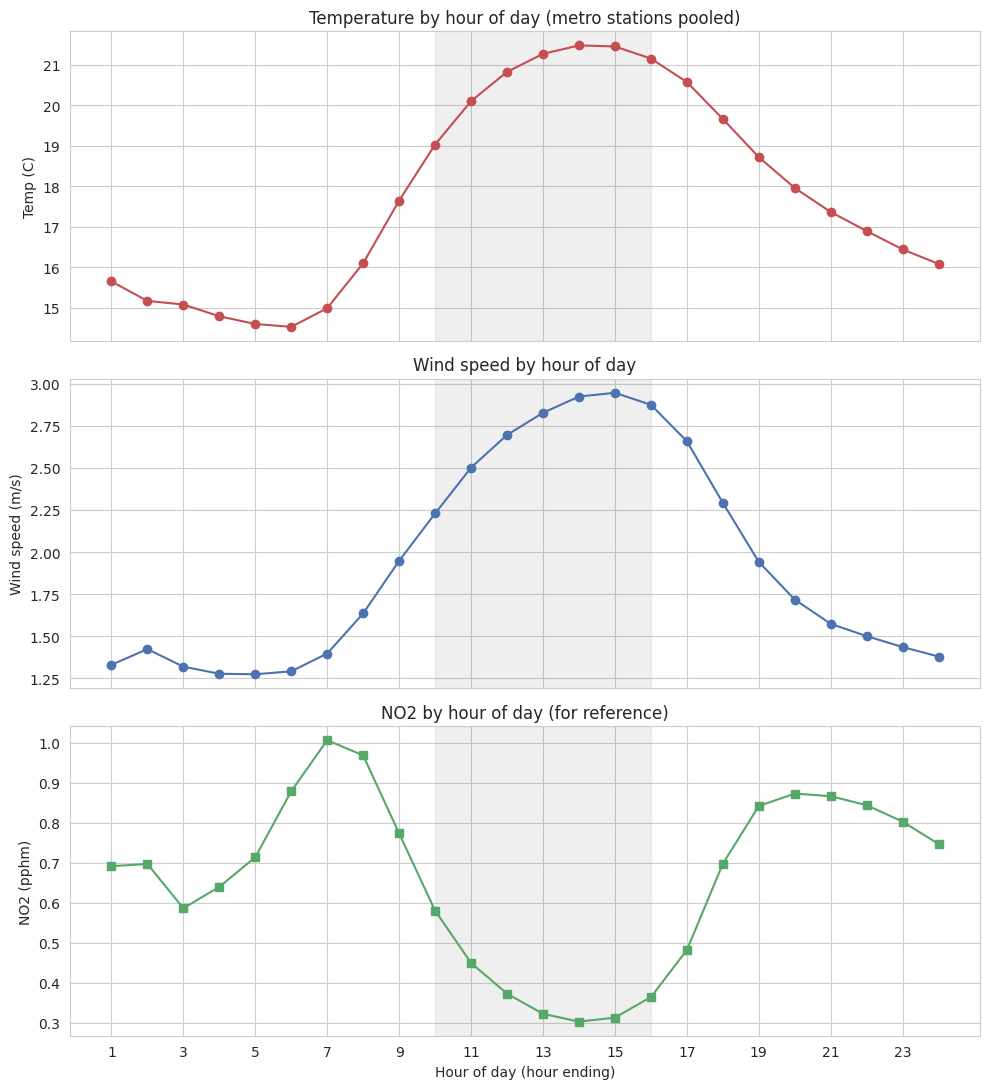

In [22]:
hourly_profile2 = hourly.groupby('hour_ending')[['temp_c','wind_speed_ms','no2_pphm']].mean()
fig, axes = plt.subplots(3, 1, figsize=(10,11), sharex=True)
axes[0].plot(hourly_profile2.index, hourly_profile2['temp_c'], marker='o', color='#C44E52')
axes[0].set_ylabel('Temp (C)'); axes[0].set_title('Temperature by hour of day (metro stations pooled)')
axes[1].plot(hourly_profile2.index, hourly_profile2['wind_speed_ms'], marker='o', color='#4C72B0')
axes[1].set_ylabel('Wind speed (m/s)'); axes[1].set_title('Wind speed by hour of day')
axes[2].plot(hourly_profile2.index, hourly_profile2['no2_pphm'], marker='s', color='#55A868')
axes[2].set_ylabel('NO2 (pphm)'); axes[2].set_title('NO2 by hour of day (for reference)')
axes[2].set_xlabel('Hour of day (hour ending)'); axes[2].set_xticks(range(1,25,2))
for ax in axes: ax.axvspan(10, 16, color='gray', alpha=0.12)
plt.tight_layout(); plt.show()

**Finding:**: Wind speed and temperature both peak around midday, when NO₂ is at its lowest. This is consistent with two contributing mechanisms: increased wind-driven dispersion and temperature/sunlight-related photochemical processes. The alignment of these patterns provides additional evidence that the hourly NO₂ pattern is influenced by more than traffic volume alone.

**Modeling implication:**: For the hourly model, `hour_of_day` should be included as a candidate feature, alongside relevant weather variables such as temp_c and wind_speed_ms. This is an important finding because the relationship between traffic and NO₂ changes throughout the day.

# Summary

## Data quality notes for the report
- `public_holiday` in the raw TfNSW export was non-functional (always 0, even on New
  Year's Day). Rebuilt using the `holidays` package's NSW calendar; now usable.
- Several stations show a synchronized dip around Aug-Oct 2024 (Part 0.3) — worth
  verifying whether this is a real event or a shared data collection gap before trusting
  that period.
- The hourly dataset is structurally limited to 8 stations (metro weather + metro NO2
  only) — the 3 BOM/rural-weather stations have no hourly source to build from.
- NO2 is right-skewed with heavy tails (Part 2.1) — consider a log-transform.
- A few NO2 readings are slightly negative — sensor noise near zero, not invalid data.

## What feature engineering should focus on
1. **`hour_of_day`** is essential for the hourly model (Part 2.9) — the traffic-NO2
   relationship reverses direction across the day due to the photochemical cycle.
2. **`aq_distance_km`** matters a lot for the daily model (Part 2.3) — weight, filter, or
   include as a feature/interaction term. Confirmed independently by the outlier analysis
   (Part 1.8): poorly-matched stations are noisier, not just weakly correlated.
3. **`is_weekend`/`day_of_week`** — statistically significant effect (Part 2.5), not just
   a visual pattern.
4. **`road_type`** — changes the sign and strength of the heavy-vehicle-% relationship
   (Part 1.6); likely useful as an interaction term, not just a control variable.
5. Avoid redundant traffic columns — `traffic_volume_total` and `traffic_volume_light`
   are highly collinear (Part 2.7); prefer total + a ratio (e.g. `heavy_pct`) over all
   three raw columns.
6. Consider two separate models: a **daily model** across the broader 11-station set, and
   an **hourly model** on the 8 metro stations with `hour_of_day` included.